Projeto Final - SCTEC
Treinamento Precificação de Imóveis

Autor: Nivaldo Marinho

O objetivo deste projeto preditivo de treinamento e prever o preço de venda de imóveis.  
Com a finalidade de ajudar a  imobiliária condado de King County (EUA) estimar o valor de venda de um imóvel com base em suas características físicas e de localização ou seja quanto cobrar por uma casa antes de colocar ela à venda.

A variável-alvo deste projeto é **`price`**, que representa o preço de venda do imóvel em dólares americanos US$.
Sendo uma variável continua ela pode assumir qualquer valor dentro os intervalos estabelecidos.

Visto que a precificação tradicional de imóveis depende da intuição e da experiência dos corretores  o que pode gerar várias inconsistências o modelo preditivo, usando essa váriável entrega uma estimativa orientada a dados, evita erros e eleva a precisão dos valores nas vendas.

In [3]:

!pip install statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("Arquivo carregado! Tem", df.shape[0], "linhas e", df.shape[1], "colunas.")

Saving kc_house_data.csv to kc_house_data.csv
Arquivo carregado! Tem 21613 linhas e 21 colunas.


In [5]:

print("VISUALIZAÇÃO RÁPIDA:")
print(df.head())

print("\nRESUMO MATEMÁTICO:")
print(df.describe())


VISUALIZAÇÃO RÁPIDA:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7      1180.0              0   
1      7242     2.0           0     0  ...      7      2170.0            400   
2     10000     1.0           0     0  ...      6       770.0              0   
3      5000     1.0           0     0  ...      7      1050.0            910   
4      8080     1.0           0     0  ...      8      1680.0              0   

   yr_built  yr_renovated  zi

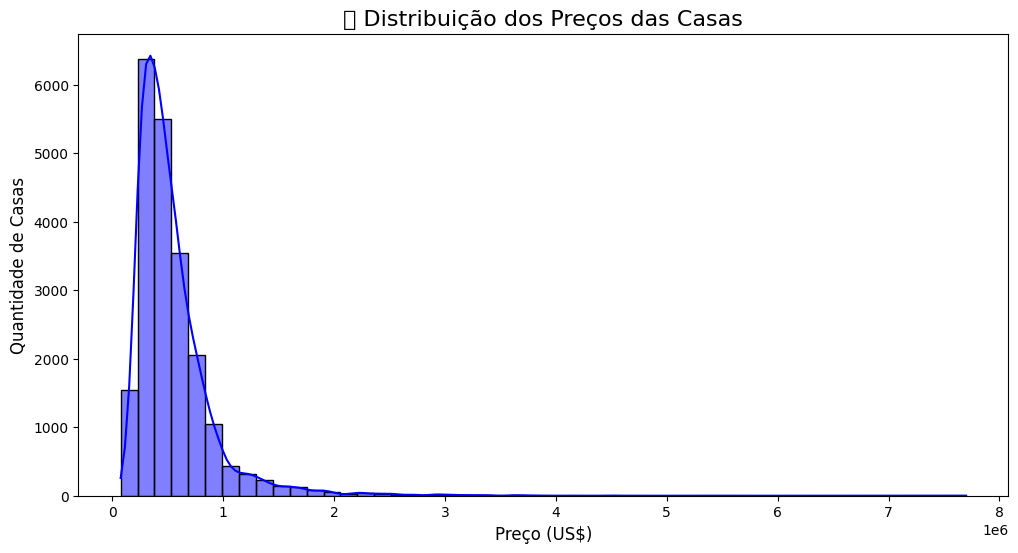

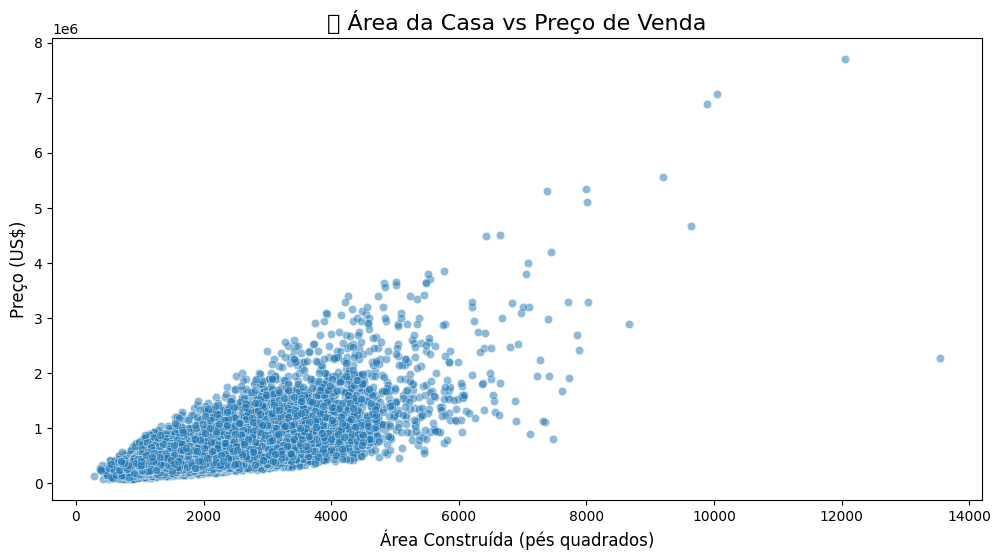

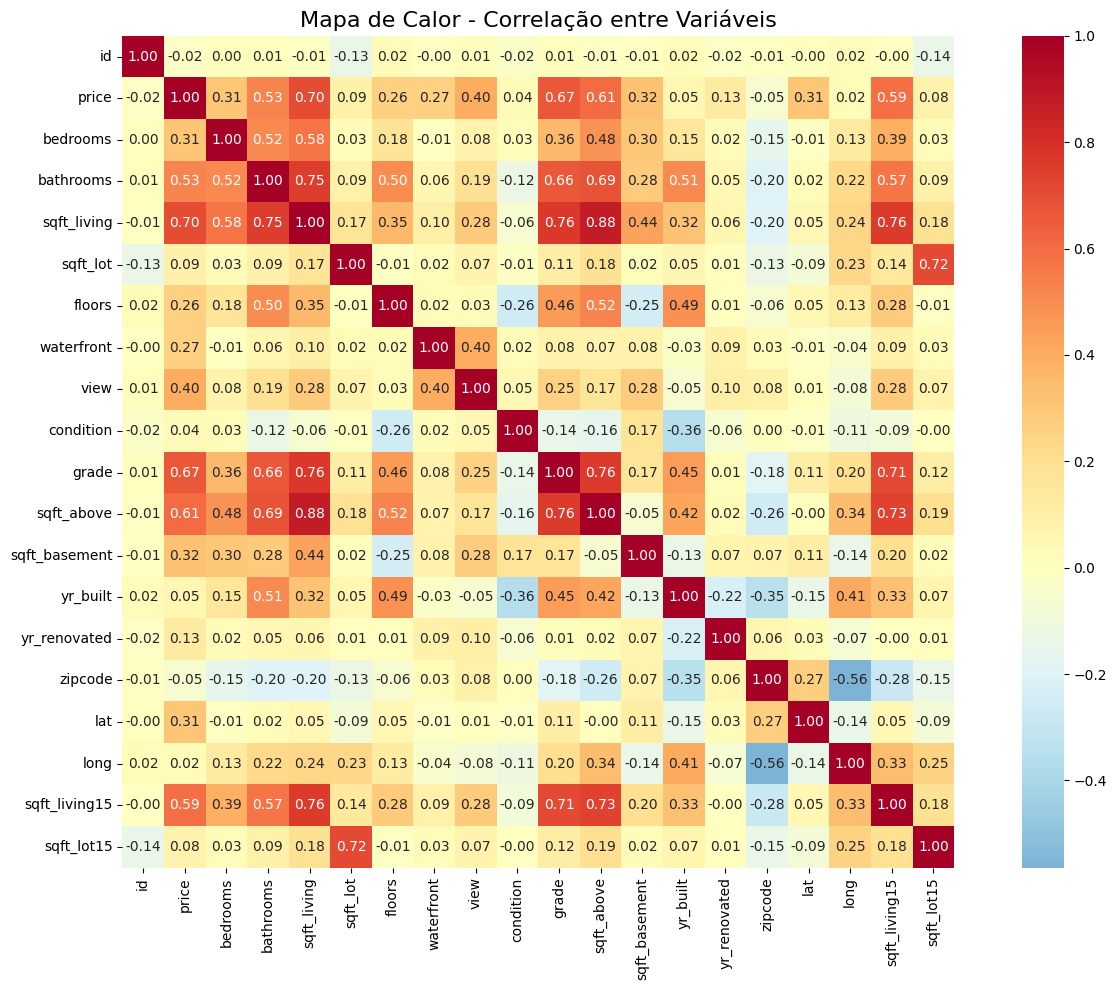

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('outputs/figures', exist_ok=True)

plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=50, kde=True, color='blue')

plt.title('📊 Distribuição dos Preços das Casas', fontsize=16)
plt.xlabel('Preço (US$)', fontsize=12)
plt.ylabel('Quantidade de Casas', fontsize=12)

plt.savefig('outputs/figures/01_histograma_preco.png')
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.5)

plt.title('🏠 Área da Casa vs Preço de Venda', fontsize=16)
plt.xlabel('Área Construída (pés quadrados)', fontsize=12)
plt.ylabel('Preço (US$)', fontsize=12)

plt.savefig('outputs/figures/02_dispersao_area_preco.png')
plt.show()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

correlacoes = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(correlacoes, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', square=True)

plt.title('Mapa de Calor - Correlação entre Variáveis', fontsize=16)
plt.tight_layout()

plt.savefig('outputs/figures/03_mapa_calor_correlacao.png')
plt.show()

Histograma de Preços (01_histograma_preco.png): Observamos que a variável price apresenta distribuição assimétrica positiva, com a maioria das casas concentradas na faixa de US$ 300.000 a US$ 600.000 e alguns dados longo de casas de luxo que se estendem até valores mais altos.

Gráfico de Dispersão (02_dispersao_area_preco.png): A correlação entre sqft_living e price é forte (positiva e linear), indicando que a área construída é um excelente preditor para o valor de mercado do imóvel.

Mapa de Calor de Correlação (03_mapa_calor_correlacao.png): Identificamos multicolinearidade entre sqft_living, sqft_above e sqft_basement, já que a área total é a soma das partes. Além disso, a variável grade mostra forte correlação positiva com o preço, sugerindo que o acabamento e a qualidade da construção são fatores determinantes na precificação.

Removemos 0 linhas duplicadas.
Espaços vazios antes: 2
Espaços vazios depois: 2
Dados limpos! Total de linhas: 21613


<Figure size 1500x800 with 0 Axes>

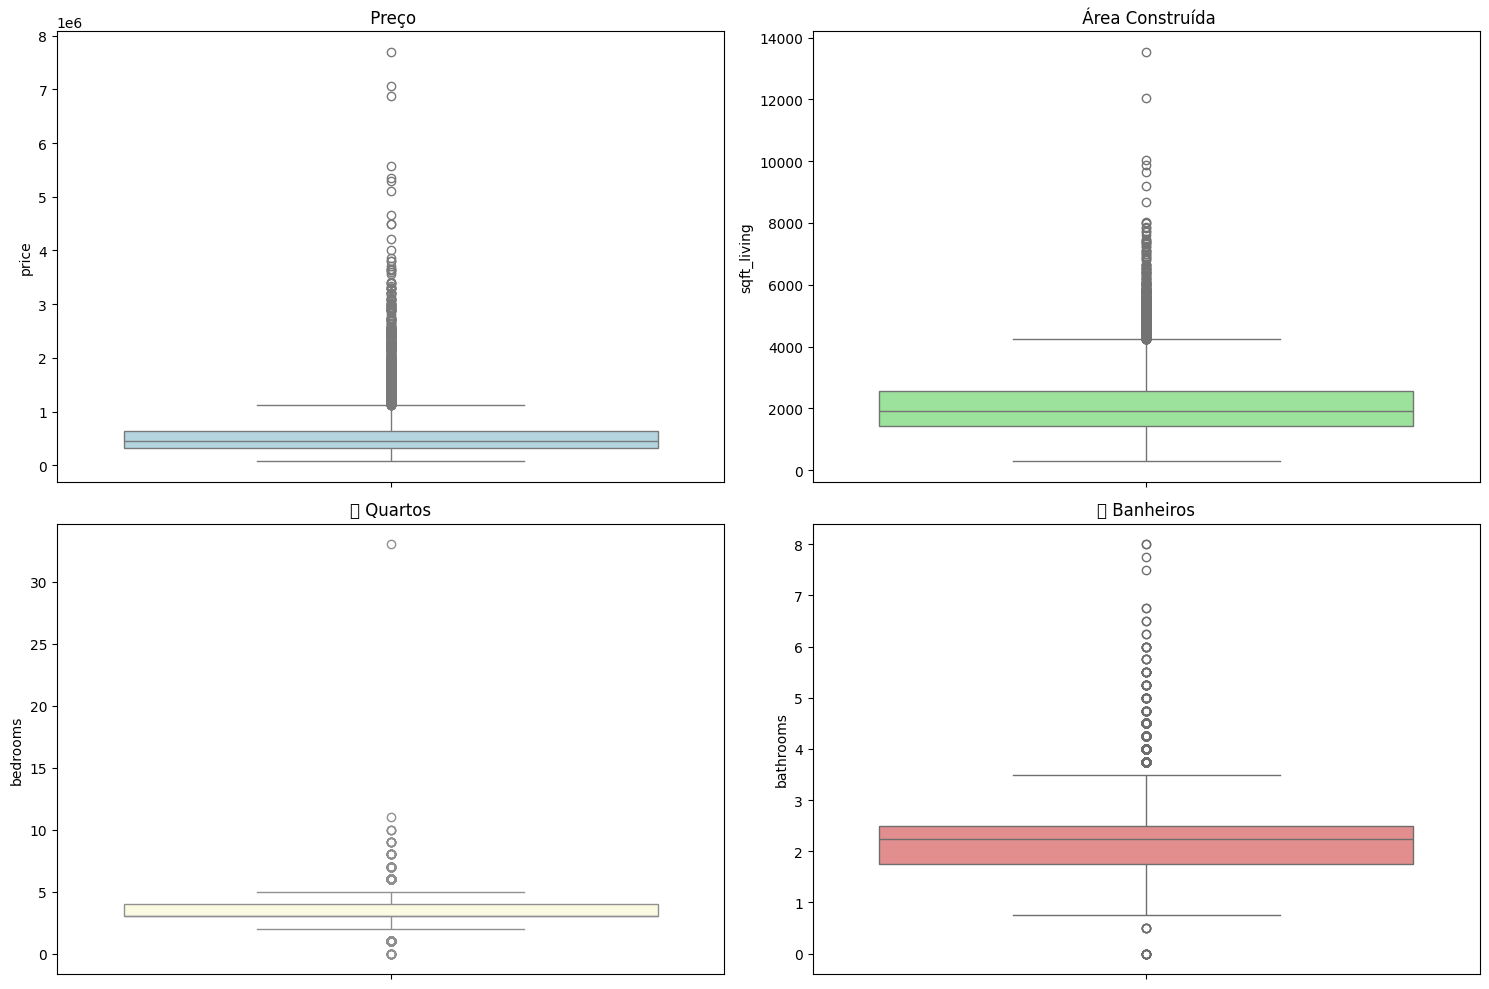

In [7]:

antes = df.shape[0]
df = df.drop_duplicates()
depois = df.shape[0]
print(f"Removemos {antes - depois} linhas duplicadas.")

print("Espaços vazios antes:", df.isnull().sum().sum())

df['sqft_basement'].fillna(df['sqft_basement'].median(), inplace=True)

df['bedrooms'].fillna(df['bedrooms'].mean(), inplace=True)

print("Espaços vazios depois:", df.isnull().sum().sum())

def cap_outliers(coluna):
    Q1 = coluna.quantile(0.25)
    Q3 = coluna.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return coluna.clip(limite_inferior, limite_superior)

df['sqft_lot'] = cap_outliers(df['sqft_lot'])
df['sqft_basement'] = cap_outliers(df['sqft_basement'])

print("Dados limpos! Total de linhas:", df.shape[0])

plt.figure(figsize=(15, 8))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(y=df['price'], ax=axes[0,0], color='lightblue')
axes[0,0].set_title(' Preço')

sns.boxplot(y=df['sqft_living'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title(' Área Construída')


sns.boxplot(y=df['bedrooms'], ax=axes[1,0], color='lightyellow')
axes[1,0].set_title('🛏️ Quartos')

sns.boxplot(y=df['bathrooms'], ax=axes[1,1], color='lightcoral')
axes[1,1].set_title('🚿 Banheiros')

plt.tight_layout()
plt.savefig('outputs/figures/04_boxplots_outliers.png')
plt.show()

Foi limpado as linhas idênticas para evitar repetir dados e distorcer a avaliação do modelo de Regressão Linear.
Foi preenchido o `sqft_basement` com a **mediana** (evita o impacto dos porões muito fora do padrão) e `bedrooms` com a **média** (por ser uma variável mais bem distribuída), sem precisar descartar informações.
* **Outliers:** Aplicamos a técnica de limite (*capping* / IQR) em `sqft_lot` e `sqft_basement`. Em vez de deletar casas grandes, apenas "suavisamos" os valores extremos para que a Regressão Linear não incline a reta e erre nas previsões.

In [8]:
ano_venda_criada = False
idade_imovel_criada = False
preco_por_m2_criada = False
foi_reformado_criada = False

# Criar ano_venda e idade_imovel
if 'date' in df.columns and 'yr_built' in df.columns:
    df['ano_venda'] = df['date'].str[:4].astype(int)
    df['idade_imovel'] = df['ano_venda'] - df['yr_built']
    df['idade_imovel'] = df['idade_imovel'].clip(lower=0)
    ano_venda_criada = True
    idade_imovel_criada = True
else:
    print("Atenção: A coluna 'date' ou 'yr_built' não foi encontrada. 'ano_venda' e 'idade_imovel' não foram criadas.")

# Criar preco_por_m2
if 'price' in df.columns and 'sqft_living' in df.columns:
    # Evitar divisão por zero
    df['preco_por_m2'] = df['price'] / df['sqft_living'].replace(0, pd.NA)
    df['preco_por_m2'].fillna(0, inplace=True) # Preencher NaNs resultantes da divisão por zero
    preco_por_m2_criada = True
else:
    print("Atenção: As colunas 'price' ou 'sqft_living' não foram encontradas. 'preco_por_m2' não foi criada.")

# Criar foi_reformado
if 'yr_renovated' in df.columns:
    df['foi_reformado'] = (df['yr_renovated'] > 0).astype(int)
    foi_reformado_criada = True
else:
    print("Atenção: A coluna 'yr_renovated' não foi encontrada. 'foi_reformado' não foi criada.")

print("✅ Novas variáveis criadas com sucesso (se as colunas originais existiam)!")

# Filtrar colunas para exibição com base na existência
colunas_para_exibir = []
if 'date' in df.columns: colunas_para_exibir.append('date')
if 'yr_built' in df.columns: colunas_para_exibir.append('yr_built')
if 'idade_imovel' in df.columns: colunas_para_exibir.append('idade_imovel')
if 'price' in df.columns: colunas_para_exibir.append('price')
if 'sqft_living' in df.columns: colunas_para_exibir.append('sqft_living')
if 'preco_por_m2' in df.columns: colunas_para_exibir.append('preco_por_m2')
if 'yr_renovated' in df.columns: colunas_para_exibir.append('yr_renovated')
if 'foi_reformado' in df.columns: colunas_para_exibir.append('foi_reformado')

if colunas_para_exibir:
    print(df[colunas_para_exibir].head())
else:
    print("Nenhuma das colunas esperadas para visualização foi encontrada no DataFrame.")

✅ Novas variáveis criadas com sucesso (se as colunas originais existiam)!
              date  yr_built  idade_imovel     price  sqft_living  \
0  20141013T000000      1955            59  221900.0         1180   
1  20141209T000000      1951            63  538000.0         2570   
2  20150225T000000      1933            82  180000.0          770   
3  20141209T000000      1965            49  604000.0         1960   
4  20150218T000000      1987            28  510000.0         1680   

   preco_por_m2  yr_renovated  foi_reformado  
0    188.050847             0              0  
1    209.338521          1991              1  
2    233.766234             0              0  
3    308.163265             0              0  
4    303.571429             0              0  


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


colunas_para_excluir = ['id', 'date', 'ano_venda', 'preco_por_m2', 'zipcode']

X = df.drop(columns=[col for col in colunas_para_excluir if col in df.columns] + ['price'])
y = df['price']

print("Colunas que o modelo vai usar:")
print(X.columns.tolist())

for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

for col in X.select_dtypes(include=np.number).columns:
    if X[col].isnull().any():
        X[col].fillna(X[col].median(), inplace=True)

vif_data = pd.DataFrame()
vif_data["Coluna"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data.sort_values('VIF', ascending=False))

while vif_data['VIF'].max() > 10:
    coluna_remover = vif_data.loc[vif_data['VIF'].idxmax(), 'Coluna']
    print(f"Removendo '{coluna_remover}' (VIF = {vif_data['VIF'].max():.2f})")
    X = X.drop(columns=coluna_remover)

    vif_data = pd.DataFrame()
    vif_data["Coluna"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]

print("\n✅ Colunas finais após tratar multicolinearidade:")
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f" Dados de TREINO: {X_train.shape[0]} casas")
print(f" Dados de TESTE:  {X_test.shape[0]} casas")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("✅ Dados escalonados!")
if 'sqft_living' in X.columns:
    print(f"Antes: área variava de {X['sqft_living'].min()} a {X['sqft_living'].max()}")
    print(f"Depois: todos os valores ficam próximos de 0 (média=0, std=1)")
else:
    print("A coluna 'sqft_living' não está mais no DataFrame após o tratamento de multicolinearidade.")

print("Dados prontos para o robô!")

Colunas que o modelo vai usar:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'idade_imovel', 'foi_reformado']
           Coluna           VIF
11       yr_built  1.145102e+06
14           long  1.097538e+06
13            lat  1.318142e+05
12   yr_renovated  1.682783e+04
18  foi_reformado  1.682687e+04
2     sqft_living  1.115063e+03
9      sqft_above  8.898750e+02
17   idade_imovel  8.698502e+02
8           grade  1.483456e+02
10  sqft_basement  6.249692e+01
7       condition  3.518040e+01
1       bathrooms  2.898952e+01
15  sqft_living15  2.818952e+01
0        bedrooms  2.351167e+01
4          floors  1.943932e+01
3        sqft_lot  7.696469e+00
16     sqft_lot15  1.637436e+00
6            view  1.557093e+00
5      waterfront  1.225149e+00
Removendo 'yr_built' (VIF = 1145101.90)
Removendo 'lat' (VIF = 120566.55)
Removendo 

In [10]:

from sklearn.linear_model import LinearRegression
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

print("Modelo treinado!")

coeficientes = pd.DataFrame({
    'Caracteristica': X.columns,
    'Peso': modelo_lr.coef_
}).sort_values('Peso', key=abs, ascending=False)

print("\n📊 Pesos do modelo (importância de cada característica):")
print(coeficientes)

y_pred_train = modelo_lr.predict(X_train_scaled)

y_pred_test = modelo_lr.predict(X_test_scaled)

from sklearn.metrics import mean_squared_error

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(" COMPARAÇÃO TREINO vs TESTE:")
print(f"RMSE no TREINO: US$ {rmse_train:,.2f}")
print(f"RMSE no TESTE:  US$ {rmse_test:,.2f}")

diferenca = rmse_test - rmse_train
if diferenca > rmse_train * 0.1:
    print(f"\n⚠️ POSSÍVEL OVERFITTING! Diferença: US$ {diferenca:,.2f}")
    print("O modelo 'decorou' os exercícios mas não generalizou bem!")
else:
    print(f"\n✅ Modelo generaliza bem! Diferença aceitável.")

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

modelo_knn = KNeighborsRegressor(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)
y_pred_knn = modelo_knn.predict(X_test_scaled)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

modelo_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
modelo_tree.fit(X_train_scaled, y_train)
y_pred_tree = modelo_tree.predict(X_test_scaled)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print(" COMPARAÇÃO DE MODELOS (RMSE - quem erra MENOS ganha):")
print(f"Regressão Linear:  US$ {rmse_test:,.2f}")
print(f"KNN:               US$ {rmse_knn:,.2f}")
print(f"Árvore de Decisão: US$ {rmse_tree:,.2f}")

melhor_rmse = min(rmse_test, rmse_knn, rmse_tree)
if melhor_rmse == rmse_test:
    print("\n CAMPEÃO: Regressão Linear!")
    modelo_campeao = modelo_lr
    y_pred_campeao = y_pred_test
elif melhor_rmse == rmse_knn:
    print("\n CAMPEÃO: KNN!")
    modelo_campeao = modelo_knn
    y_pred_campeao = y_pred_knn
else:
    print("\n CAMPEÃO: Árvore de Decisão!")
    modelo_campeao = modelo_tree
    y_pred_campeao = y_pred_tree

Modelo treinado!

📊 Pesos do modelo (importância de cada característica):
  Caracteristica           Peso
1         floors  146341.560571
4  sqft_basement  105139.505538
3           view   81648.780545
0       sqft_lot   79113.171804
2     waterfront   39919.257391
6   idade_imovel   30508.251839
7  foi_reformado   17517.164121
5     sqft_lot15  -12560.003506
 COMPARAÇÃO TREINO vs TESTE:
RMSE no TREINO: US$ 292,729.73
RMSE no TESTE:  US$ 308,950.36

✅ Modelo generaliza bem! Diferença aceitável.
 COMPARAÇÃO DE MODELOS (RMSE - quem erra MENOS ganha):
Regressão Linear:  US$ 308,950.36
KNN:               US$ 307,420.02
Árvore de Decisão: US$ 321,175.63

 CAMPEÃO: KNN!


In [11]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred_campeao)
mse = mean_squared_error(y_test, y_pred_campeao)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_campeao)

print("=" * 50)
print("📊 MÉTRICAS DO MODELO CAMPEÃO")
print("=" * 50)
print(f"MAE:  US$ {mae:,.2f}")
print(f"      → Em média, erra US$ {mae:,.0f} para mais ou para menos")
print(f"MSE:  US$ {mse:,.2f}")
print(f"      → Erro quadrático (difícil de interpretar)")
print(f"RMSE: US$ {rmse:,.2f}")
print(f"      → Raiz do erro, na mesma unidade do preço")
print(f"R²:   {r2:.4f}")
print(f"      → Explica {r2*100:.1f}% da variação dos preços")
print("=" * 50)

📊 MÉTRICAS DO MODELO CAMPEÃO
MAE:  US$ 188,227.00
      → Em média, erra US$ 188,227 para mais ou para menos
MSE:  US$ 94,507,068,991.08
      → Erro quadrático (difícil de interpretar)
RMSE: US$ 307,420.02
      → Raiz do erro, na mesma unidade do preço
R²:   0.3749
      → Explica 37.5% da variação dos preços


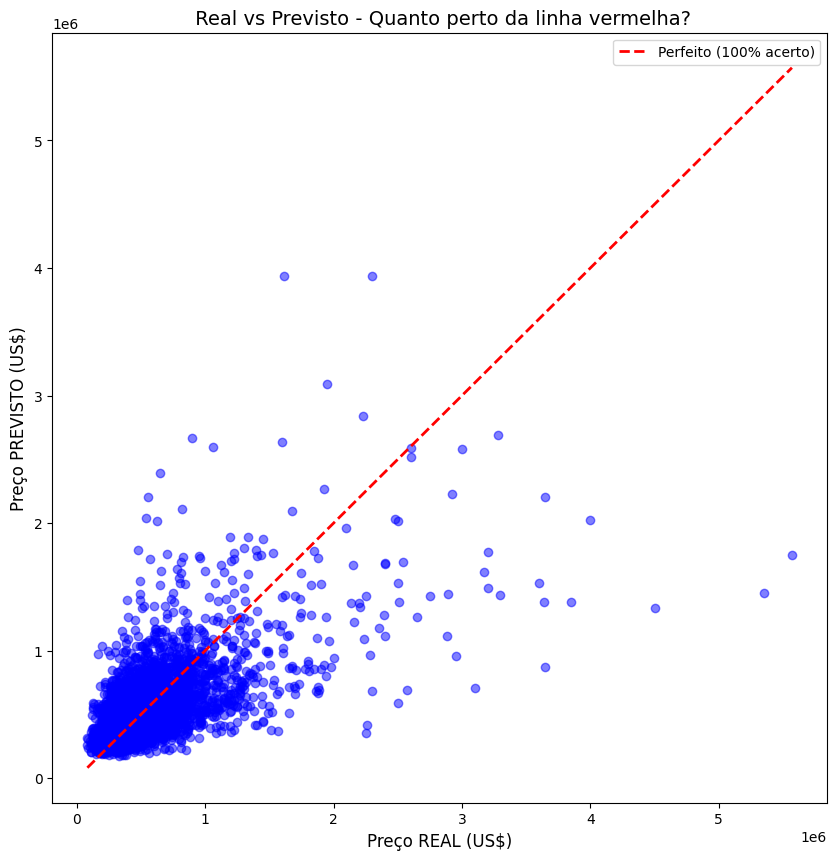

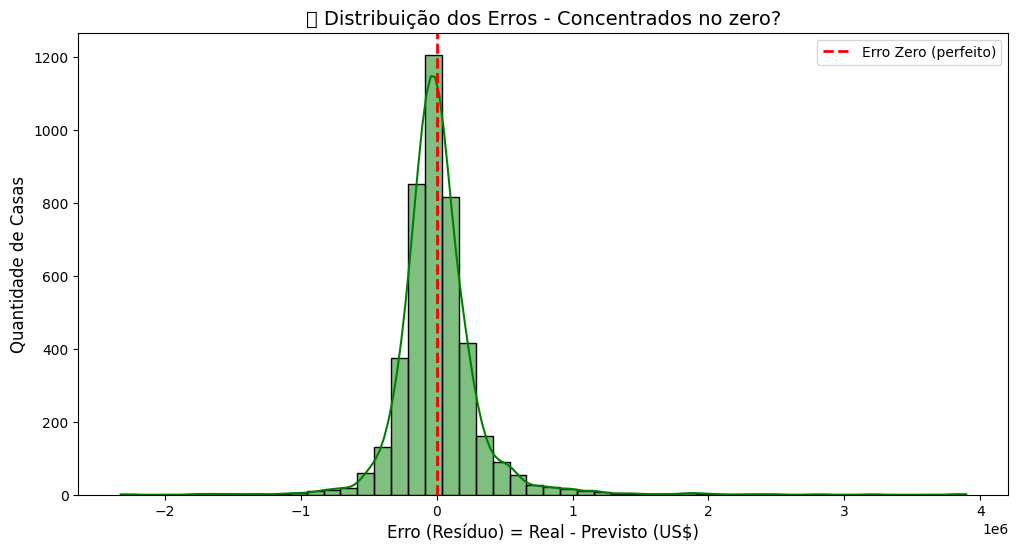

In [12]:
plt.figure(figsize=(10, 10))

plt.scatter(y_test, y_pred_campeao, alpha=0.5, color='blue')

min_val = min(y_test.min(), y_pred_campeao.min())
max_val = max(y_test.max(), y_pred_campeao.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfeito (100% acerto)')

plt.xlabel('Preço REAL (US$)', fontsize=12)
plt.ylabel('Preço PREVISTO (US$)', fontsize=12)
plt.title(' Real vs Previsto - Quanto perto da linha vermelha?', fontsize=14)
plt.legend()

plt.savefig('outputs/figures/05_real_vs_previsto.png')
plt.show()

residuos = y_test - y_pred_campeao

plt.figure(figsize=(12, 6))

sns.histplot(residuos, bins=50, kde=True, color='green')

plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Erro Zero (perfeito)')

plt.xlabel('Erro (Resíduo) = Real - Previsto (US$)', fontsize=12)
plt.ylabel('Quantidade de Casas', fontsize=12)
plt.title('📊 Distribuição dos Erros - Concentrados no zero?', fontsize=14)
plt.legend()

plt.savefig('outputs/figures/06_residuos.png')
plt.show()



O modelo K-Nearest Neighbors (KNN) foi o campeão entre os algoritmos testados, apresentando RMSE de US$ 307.420,02, superando a Regressão Linear (US$ 308.950,36) e a Árvore de Decisão (US$ 321.175,63).

Em termos práticos, o modelo erra, em média, US$ 188.227,00 por previsão (MAE), o que equivale a aproximadamente 35% do valor do imóvel. O coeficiente R² de 0,3749 indica que apenas 37,5% da variação dos preços é explicada pelas características utilizadas, enquanto os 62,5% restantes dependem de fatores não incluídos, como localização, qualidade da construção e condições de mercado.

A análise gráfica revelou que o modelo captura tendências gerais, mas apresenta alta dispersão nas previsões, especialmente para imóveis de alto valor, que tendem a ser subestimados. Os erros estão centrados em zero, indicando ausência de viés sistemático.
As variáveis mais influentes foram número de andares, área do porão e vista para água. Idade do imóvel e reforma também impactam positivamente o preço.
Embora seja o melhor entre os testados, o modelo ainda possui margem significativa de melhoria. Recomenda-se adicionar variáveis de localização, aplicar transformação logarítmica no preço e testar algoritmos mais avançados como Random Forest ou XGBoost para aumentar a precisão das previsões.

Onde o modelo vacila: Casas de luxo (acima de US$ 1 milhão) ou imóveis com características muito raras (vista para a água, terrenos gigantes), pois envolvem fatores subjetivos.

Recomendação: O modelo deve ser usado como uma ferramenta de triagem rápida para precificar o catálogo, mas nunca feche negócio sem a avaliação presencial de um corretor.

In [13]:
import joblib
import os
import json
from datetime import datetime
import shutil
from google.colab import files

os.makedirs('models/v1', exist_ok=True)

joblib.dump(modelo_campeao, 'models/v1/modelo_regressao_v1.pkl')
print("✅ Robô salvo em 'models/v1/modelo_regressao_v1.pkl'")

joblib.dump(scaler, 'models/v1/scaler_v1.pkl')
print("✅ Scaler salvo em 'models/v1/scaler_v1.pkl'")

metricas = {
    "versao": "v1",
    "data_treinamento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "modelo_escolhido": type(modelo_campeao).__name__,
    "variaveis_preditores": list(X.columns),
    "numero_variaveis": len(X.columns),
    "metricas": {
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2)
    },
    "tamanho_treino": len(X_train),
    "tamanho_teste": len(X_test),
    "random_seed": 42,
    "escalonador": "StandardScaler"
}

with open('models/v1/metricas_v1.json', 'w') as f:
    json.dump(metricas, f, indent=4)
print("✅ Métricas salvas em 'models/v1/metricas_v1.json'")

shutil.make_archive('projeto_final', 'zip', 'models')
print(" Arquivo 'projeto_final.zip' criado!")

files.download('projeto_final.zip')

print("\n PROJETO CONCLUÍDO COM SUCESSO!")
print(" Baixe também o notebook pelo menu: Arquivo > Baixar > Baixar .ipynb")

!zip -r graficos_projeto.zip outputs/figures/
from google.colab import files
files.download('graficos_projeto.zip')

✅ Robô salvo em 'models/v1/modelo_regressao_v1.pkl'
✅ Scaler salvo em 'models/v1/scaler_v1.pkl'
✅ Métricas salvas em 'models/v1/metricas_v1.json'
 Arquivo 'projeto_final.zip' criado!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 PROJETO CONCLUÍDO COM SUCESSO!
 Baixe também o notebook pelo menu: Arquivo > Baixar > Baixar .ipynb
  adding: outputs/figures/ (stored 0%)
  adding: outputs/figures/06_residuos.png (deflated 11%)
  adding: outputs/figures/05_real_vs_previsto.png (deflated 7%)
  adding: outputs/figures/04_boxplots_outliers.png (deflated 22%)
  adding: outputs/figures/02_dispersao_area_preco.png (deflated 6%)
  adding: outputs/figures/03_mapa_calor_correlacao.png (deflated 5%)
  adding: outputs/figures/01_histograma_preco.png (deflated 14%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
requirements_content = """pandas
numpy
matplotlib
seaborn
scikit-learn
statsmodels
joblib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("✅ Arquivo requirements.txt criado com sucesso!")

✅ Arquivo requirements.txt criado com sucesso!
